## Testing the Gadget for the $^{42}\text{Ca}$ in the Quasiparticle Picture

### Imports

In [11]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import get_twobody_nuclearshell_model,SingleParticleState
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh,expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import QuasiParticlesConverter,HardcoreBosonsBasis,QuasiParticlesConverterOnlynnpp
from src.utils import generate_particleconservation_basis,array_to_qutip

### Load the coupling of the Quasiparticle Hamiltonian

We upload the $g^{(1)}_{AB}$ couplings from the numpy dictionary, we also fix the number of Qubit for the system that we are considering. Since the $^{6}\text{Be}$ involves only one active quasiparticle proton, we don't need any two-body interaction

In [12]:
data_onebody=np.load('data/matrix_elements_h_eff_2body/one_body_nn_pf.npz')
keys=data_onebody['keys']
values=data_onebody['values']
n_qubits=10

g_onebody={}
diagonal_elements=np.zeros(n_qubits)
g_matrix=np.zeros((n_qubits,n_qubits))
for a,key in enumerate(keys):
    i,j=key
    g_onebody[(i,j)]=values[a]
    if i!=j:
        g_matrix[i,j]=values[a]
    if i==j:
        diagonal_elements[i]=values[a]    
        
        
# get the computational basis of the space
basis=computational_basis(n_qubits)


#### Study the Quasiparticle Hamiltonian with the Hardcore Boson Basis

In [13]:
nparticles_a=1
nparticles_b=0

particle_conserved_basis=generate_particleconservation_basis(size_a=n_qubits,size_b=n_qubits,nparticles_a=nparticles_a,nparticles_b=nparticles_b)

print(particle_conserved_basis)

# initialize the class in the number sector of the quasiparticle space (see NSMFermion library)
HBB=HardcoreBosonsBasis(basis=particle_conserved_basis)
quasiparticle_nsm_hamiltonian_particle_conserved=0.
for key,value in g_onebody.items():
    idx_a,idx_b=key
    quasiparticle_nsm_hamiltonian_particle_conserved+=value*HBB.adag_a_matrix(idx_a,idx_b)



print(quasiparticle_nsm_hamiltonian_particle_conserved)
value,_=np.linalg.eigh(quasiparticle_nsm_hamiltonian_particle_conserved.todense())

print(value)

[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]]
<List of Lists sparse matrix of dtype 'float64'
	with 100 stored elements and shape (10, 10)>
  Coords	Values
  (0, 0)	-18.371668181818183
  (0, 1)	0.6098090909090912
  (0, 2)	-0.2980136363636365
  (0, 3)	0.20700909090909111
  (0, 4)	-0.36278567700730024
  (0, 5)	0.14449272781592892
  (0, 6)	-0.5229142196987457
  (0, 7)	0.36469197027018596
  (0, 8)	-0.3102801485457036
  (0, 9)	-0.19
  (1, 0)	0.6098090909090912
  (1, 1)	-17.83716168831169
  (1, 2)	0.6375103896103895
  (1, 3)	-0.4020188311688312
  (1, 4)	0.269231555925284
  (1, 5)	-0.23804684889794517
  (1, 6)	0.40

#### Write the NSM Quasiparticle Hamiltonian

In [14]:
hamiltonian_xy=0.
for i in range(n_qubits):
    for j in range(i+1,n_qubits):
        hamiltonian_xy+=SpinOperator([('x',i,'x',j)],coupling=[0.5*g_matrix[i,j]],size=n_qubits,verbose=1).qutip_op
        hamiltonian_xy+=SpinOperator([('y',i,'y',j)],coupling=[0.5*g_matrix[i,j]],size=n_qubits,verbose=1).qutip_op
hamiltonian_z=0.
for i in range(n_qubits):
    hamiltonian_z+=SpinOperator([('qz',i)],coupling=[diagonal_elements[i]],size=n_qubits,verbose=1).qutip_op
nsm_quasiparticle_hamiltonian=hamiltonian_z+hamiltonian_xy

In [15]:

eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [17]:
print(eigenvalues_nsm)
gs_idx = np.argmin(np.abs(eigenvalues_nsm - value[0]))
print(eigenstates_nsm[gs_idx].full())
print(gs_idx)



[-114.2903     -111.91088444 -110.66428088 ...   -3.22444542   -2.92812418
    0.        ]
[[ 0.        +0.j]
 [-0.0513372 +0.j]
 [-0.05624037+0.j]
 ...
 [ 0.        +0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]]
990


Now, we get the spectrum of this Hamiltonian

### Puzzle of the Effective interaction

Following our notes on the gadget, we need to verify if we can reproduce the interaction by using the transverse field per site $d_i$. Since the relevant term in the effective Hamiltonian comes out as $H_{\text{int,eff}}=-\frac{1}{\gamma}\sum_{A \neq B} d_A d_B (X_A X_B +Y_A Y_B)$. We need to figure out if we can solve the condition $g_{AB}=-d_A d_B$. To do so, we treat it as an optimization problem. 

Optimal drive parameters: [-0.50700705  0.59487242 -0.6160578   0.56638526 -0.75691226  0.76236622
 -0.57893056  0.61455154 -0.59645235 -0.66705995]
Optimized effective interaction matrix:
 [[ 0.         -0.30820458 -0.01433202  0.08015223 -0.02097418  0.24203233
   0.22939234 -0.05311     0.0078746  -0.1482041 ]
 [-0.30820458  0.         -0.27103459  0.06509186  0.18103467 -0.21546379
  -0.06550851  0.04994316 -0.01765204  0.20681557]
 [-0.01433202 -0.27103459  0.         -0.4612129  -0.25943956  0.1692454
  -0.01033871 -0.03552623  0.06999574 -0.22094749]
 [ 0.08015223  0.06509186 -0.4612129   0.          0.25302652 -0.10019203
   0.00984447  0.05476844 -0.13916987  0.18781293]
 [-0.02097418  0.18103467 -0.25943956  0.25302652  0.          0.06314434
   0.03113059 -0.05123823  0.08847253  0.55066314]
 [ 0.24203233 -0.21546379  0.1692454  -0.10019203  0.06314434  0.
  -0.10642246  0.03219662 -0.02246004 -0.54702502]
 [ 0.22939234 -0.06550851 -0.01033871  0.00984447  0.03113059 -0.1064

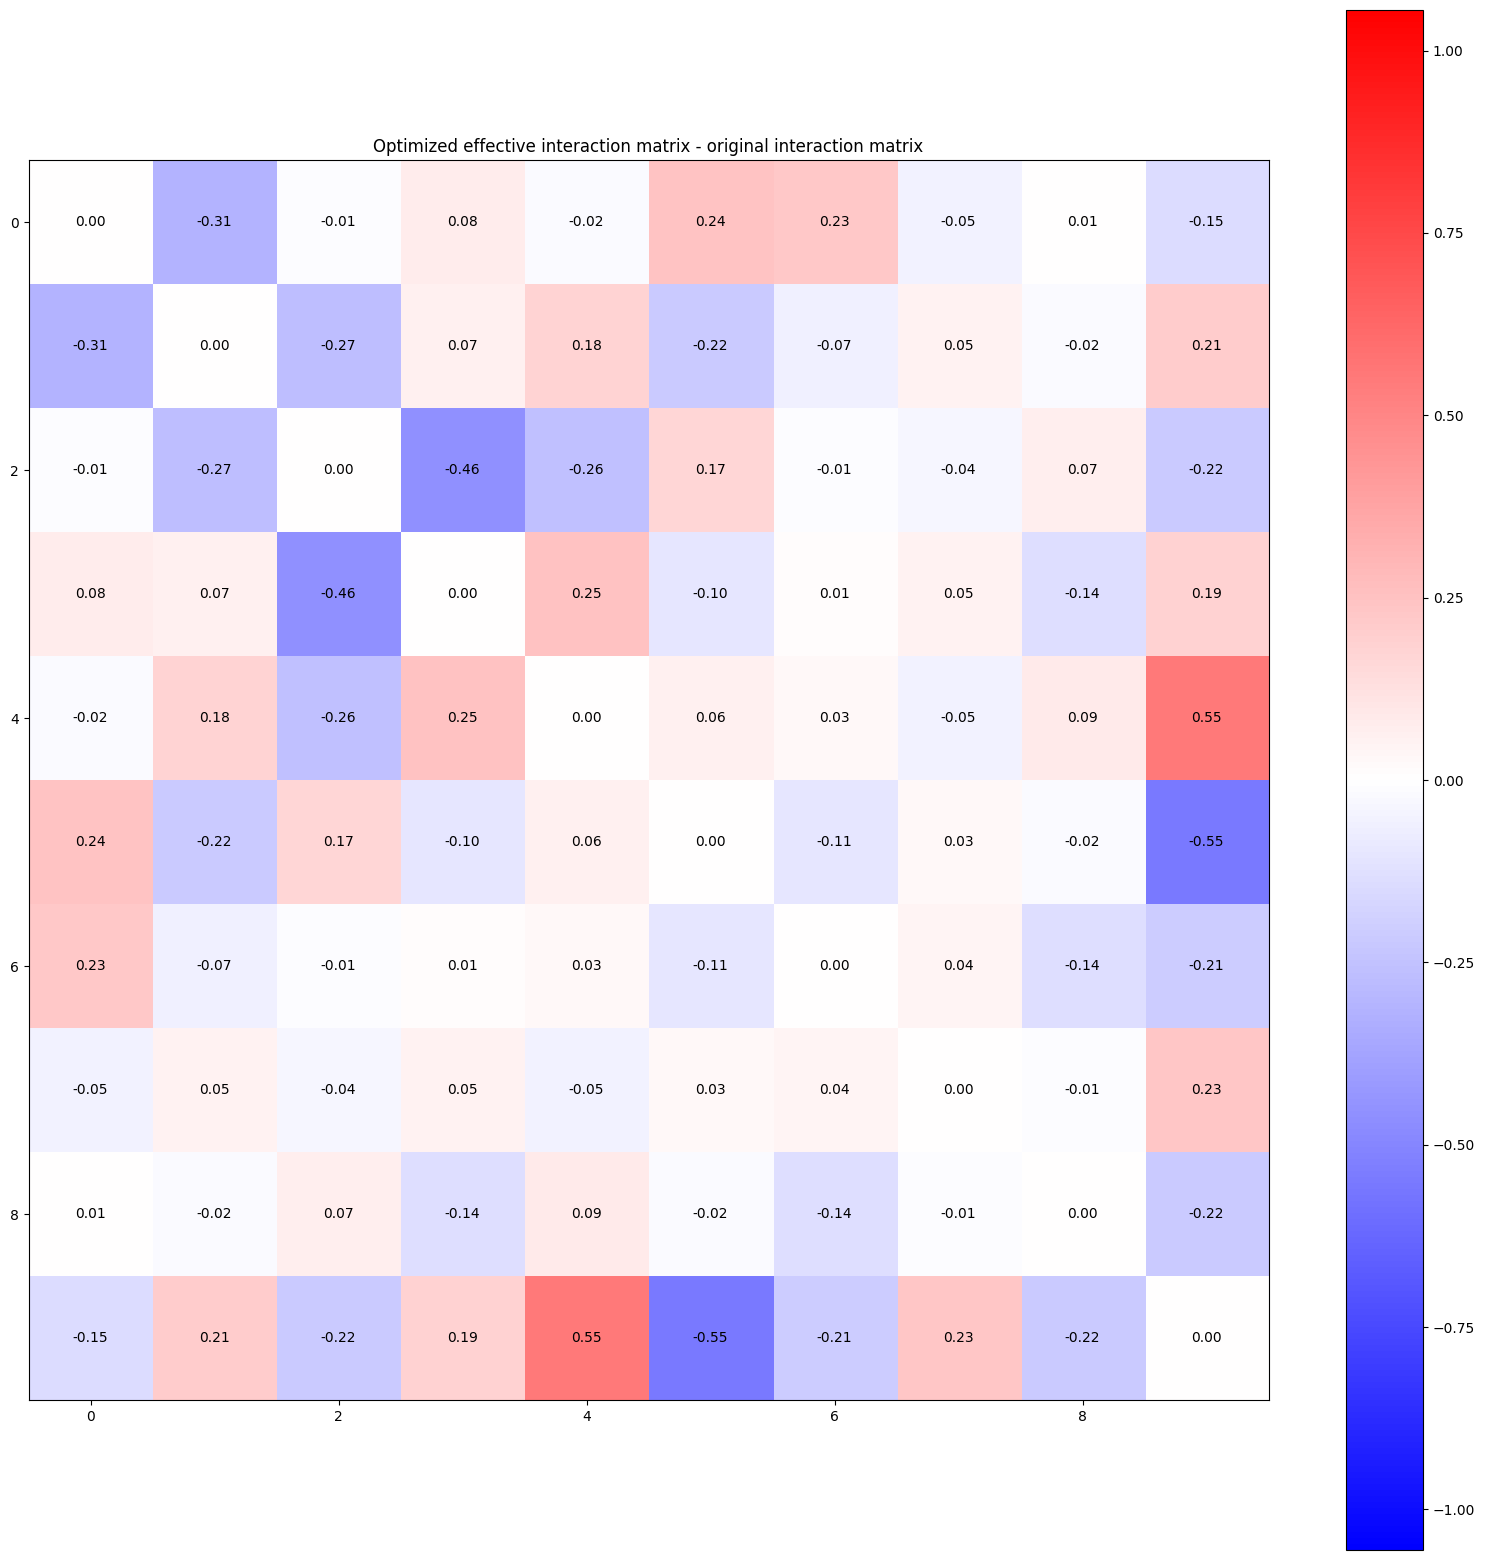

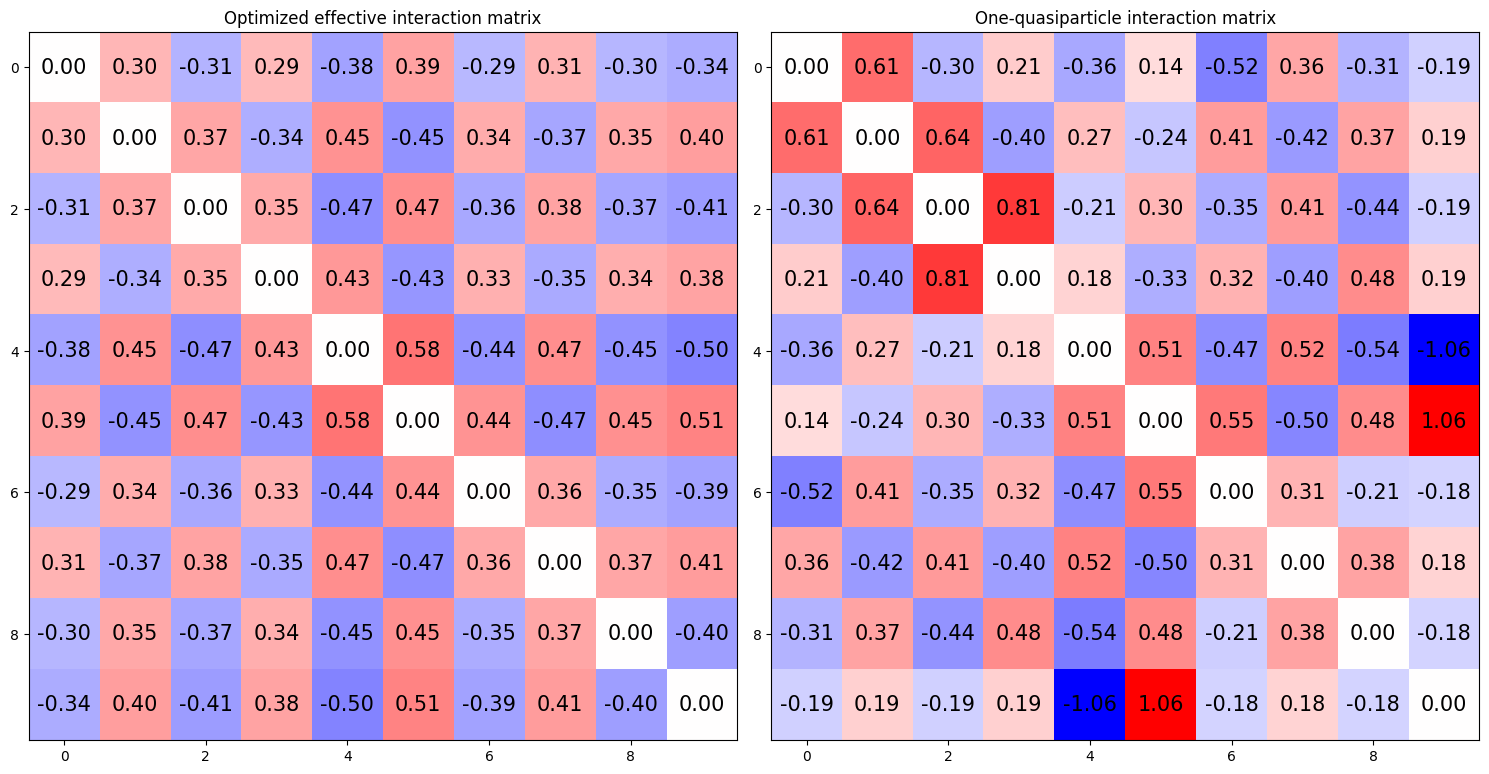

In [18]:
OptimalFieldBe6=EffectiveInteractionOptimizer(nqubit=n_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print("Optimized effective interaction matrix:\n", OptimalFieldBe6.reconstructed(d_opt)-g_matrix)
plt.figure(figsize=(20,20))
plt.imshow(OptimalFieldBe6.reconstructed(d_opt)-g_matrix, cmap='bwr', vmin=-np.max(np.abs(g_matrix)), vmax=np.max(np.abs(g_matrix)))
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(j, i, f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}", ha='center', va='center', color='black')
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

vmax = np.max(np.abs(g_matrix))
matrices = [OptimalFieldBe6.reconstructed(d_opt), g_matrix]
titles = ["Optimized effective interaction matrix", 
          "One-quasiparticle interaction matrix"]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap='bwr', vmin=-vmax, vmax=vmax)
    for i in range(n_qubits):
        for j in range(n_qubits):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', color='black',fontsize=15)
    #plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Write the Diagonal part of the Ising Hamiltonian

Now, we have to write the full ising Hamiltonian that describes the constrain subspace, where our effective Hamiltonian acts, and then see how the spectrum behaves

#### Define the hamiltonian $H_z$ out of the couplings and constrains

In [19]:
# get the total particle constrain 
gamma=100
ntot=1
# we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
effective_longitudinal_field=(diagonal_elements+0.5*(d_opt**2).sum())/(gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz=0.
for i in range(n_qubits):
    for j in range(i+1,n_qubits):
        hamiltonian_zz+=SpinOperator([('qz',i,'qz',j)],coupling=[2*gamma],size=n_qubits,verbose=1).qutip_op

# then the linear terms
hamiltonian_z=0.
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z+=SpinOperator([('qz',i)],coupling=[effective_longitudinal_field[i]+gamma*(1-2*ntot)],size=n_qubits,verbose=1).qutip_op

#finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space=qt.tensor([qt.qeye(2)] * n_qubits)

longitudinal_hamiltonian=hamiltonian_zz+hamiltonian_z+gamma*(ntot**2)*identity_qubit_space


In [20]:
print(longitudinal_hamiltonian.diag())
print(basis)

[ 1.00000000e+02 -6.23143708e-02 -1.40147518e-02 ...  6.39907006e+03
  6.39911836e+03  8.09905604e+03]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]


### Part of the second step is to introduce the transverse field term

In [21]:
# the transverse field
transverse_hamiltonian=0.
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    transverse_hamiltonian+=SpinOperator([('x',i)],coupling=[d_opt[i]/np.sqrt(2)],size=n_qubits,verbose=1).qutip_op

#### Compute the spectrum of the full Hamiltonian

Once that we compute the spectrum, we expect that our ground state lies in the subspace near the $E_0=0$ region, Let's see what we get

In [22]:
total_hamiltonian=longitudinal_hamiltonian+transverse_hamiltonian
eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = total_hamiltonian.eigenstates()


#### Check the structure of the effective Hamiltonian to control the longitudinal couplings $g_{AA}$

In [23]:
print(eigenvalues_total_hamiltonian[:3])

print(fidelity(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx]))

[-0.19425456 -0.17984707 -0.17627767]
0.9915618624987553


#### Adiabatic State Preparation

We divide the initialization of the total hamiltonian, since the driver is just the 0-th component of the Z hamiltonian. We just need to tune the initialization of the other components

In [24]:
# get the total particle constrain 
gamma=15
ntot=1
# we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
effective_longitudinal_field=(diagonal_elements+0.5*(d_opt**2).sum())/(gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz=0.
for i in range(n_qubits):
    for j in range(i+1,n_qubits):
        hamiltonian_zz+=SpinOperator([('qz',i,'qz',j)],coupling=[2*gamma],size=n_qubits,verbose=1).qutip_op

# then the linear terms
hamiltonian_z=0.
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z+=SpinOperator([('qz',i)],coupling=[effective_longitudinal_field[i]+gamma*(1-2*ntot)],size=n_qubits,verbose=1).qutip_op

#finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space=qt.tensor([qt.qeye(2)] * n_qubits)

total_hamiltonian=hamiltonian_zz+hamiltonian_z+gamma*(ntot**2)*identity_qubit_space
# the transverse field is part of the variable hamiltonian
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    total_hamiltonian+=SpinOperator([('x',i)],coupling=[d_opt[i]/(np.sqrt(2))],size=n_qubits,verbose=1).qutip_op

Then the driver Hamiltonian

In [25]:
# get the total particle constrain 
ntot=1
# we define the effective longitudianl field that contributes to the driver hamiltonian hamiltonian of Be 6
external_field=np.zeros(diagonal_elements.shape[0])
external_field[0]=diagonal_elements[0]
print(external_field)

effective_longitudinal_field=(external_field)/(gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz=0.
for i in range(n_qubits):
    for j in range(i+1,n_qubits):
        hamiltonian_zz+=SpinOperator([('qz',i,'qz',j)],coupling=[2*gamma],size=n_qubits,verbose=1).qutip_op

# then the linear terms
hamiltonian_z=0.
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z+=SpinOperator([('qz',i)],coupling=[effective_longitudinal_field[i]+gamma*(1-2*ntot)],size=n_qubits,verbose=1).qutip_op

#finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space=qt.tensor([qt.qeye(2)] * n_qubits)

driver_hamiltonian=hamiltonian_zz+hamiltonian_z+gamma*(ntot**2)*identity_qubit_space

print(np.argsort(driver_hamiltonian.full().diagonal()))
idx_init=np.argsort(driver_hamiltonian.full().diagonal())[0]

[-18.37166818   0.           0.           0.           0.
   0.           0.           0.           0.           0.        ]
[ 512  256   16 ... 1021  511 1023]


Then we get the state preparation, initializing the state and evolving the interpolate hamiltonian

Time evolution

In [26]:
#### Initialize the state and convert the hamiltonians
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
total_hamiltonian_sparse=(total_hamiltonian.data.as_scipy())
driver_hamiltonian_sparse=(driver_hamiltonian.data.as_scipy() )
print(total_hamiltonian_sparse)
#initialize the state
psi=np.zeros(basis.shape[0])
print(basis[idx_init])
psi[idx_init]=1.

print(psi.conj().T @ driver_hamiltonian_sparse @ psi)

#### start the time evolution

nlevels=3
tau=200
time_steps=int(10*tau)
time=np.linspace(0,tau,time_steps)
delta_t=time[1]-time[0]
spectrum=np.zeros((time_steps,nlevels))
energy=np.zeros(time_steps)
for i,t in enumerate(time):
    hamiltonian_t_sparse=(1-t/tau)*driver_hamiltonian_sparse+(t/tau)*total_hamiltonian_sparse
    psi=expm_multiply(-1j*delta_t*hamiltonian_t_sparse,psi)
    eigenvalues, eigenvectors = eigsh(hamiltonian_t_sparse, k=nlevels, which='SA')
    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    spectrum[i] = eigenvalues
    energy[i]=psi.conj().dot(hamiltonian_t_sparse.dot( psi))  
print('final energy=',psi.conj().dot(total_hamiltonian_sparse.dot( psi)))
    

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 11264 stored elements and shape (1024, 1024)>
  Coords	Values
  (0, 0)	(15+0j)
  (0, 1)	(-0.47168261700118663+0j)
  (0, 2)	(-0.42175550006185164+0j)
  (0, 4)	(0.43455356411612134+0j)
  (0, 8)	(-0.4093657217557876+0j)
  (0, 16)	(0.5390743271809765+0j)
  (0, 32)	(-0.5352177939511877+0j)
  (0, 64)	(0.40049486107207605+0j)
  (0, 128)	(-0.43561865056869314+0j)
  (0, 256)	(0.42063832084440944+0j)
  (0, 512)	(-0.3585081254436928+0j)
  (1, 0)	(-0.47168261700118663+0j)
  (1, 1)	(-0.4154291386749236+0j)
  (1, 3)	(-0.42175550006185164+0j)
  (1, 5)	(0.43455356411612134+0j)
  (1, 9)	(-0.4093657217557876+0j)
  (1, 17)	(0.5390743271809765+0j)
  (1, 33)	(-0.5352177939511877+0j)
  (1, 65)	(0.40049486107207605+0j)
  (1, 129)	(-0.43561865056869314+0j)
  (1, 257)	(0.42063832084440944+0j)
  (1, 513)	(-0.3585081254436928+0j)
  (2, 0)	(-0.42175550006185164+0j)
  (2, 2)	(-0.09343167835746335+0j)
  (2, 3)	(-0.47168261700118663+0j)
  :	:
  (1021, 

/tmp/ipykernel_32436/1217509940.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i]=psi.conj().dot(hamiltonian_t_sparse.dot( psi))


final energy= (-1.272602812846202+1.8041124150158794e-16j)


Results of the QA state preparation

fidelity= 0.8620284892968691 -0.09712795069435991


/tmp/ipykernel_32097/2449555149.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


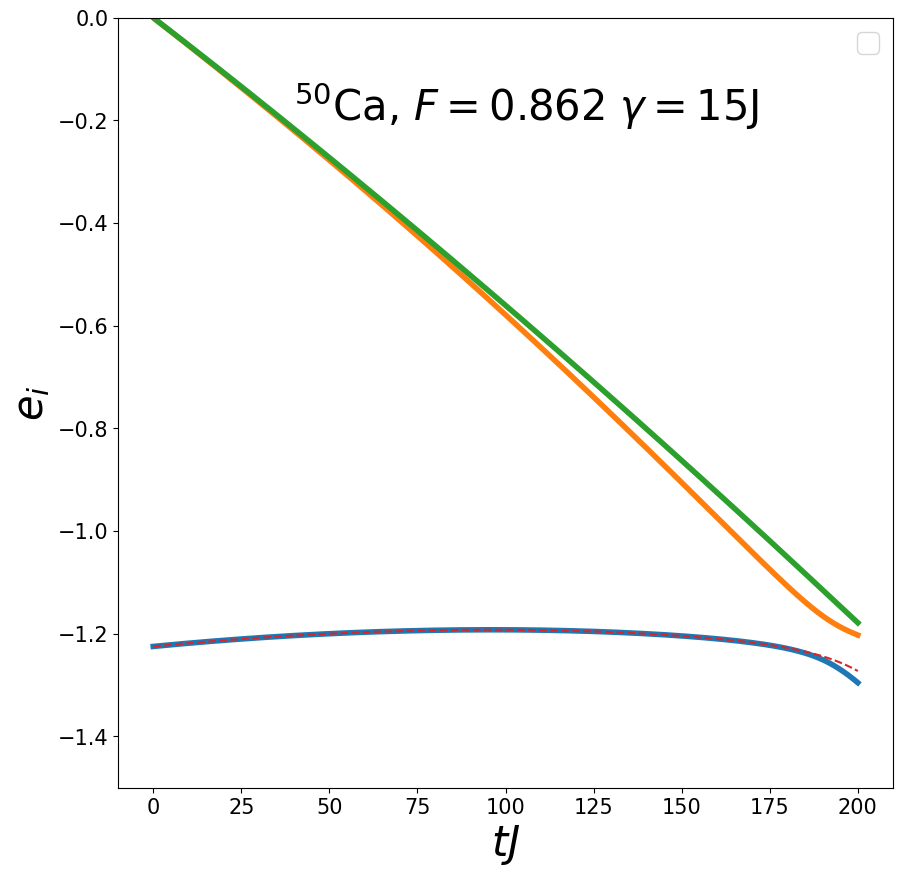

-19.08904219269303


In [46]:
plt.figure(figsize=(10,10))
plt.plot(time,spectrum,linewidth=4)
plt.plot(time,energy,linestyle='--')
psi_qutip=array_to_qutip(psi,n_qubits)
f_value=fidelity(psi_qutip,eigenstates_total_hamiltonian[0])
print('fidelity=',fidelity(psi_qutip,eigenstates_total_hamiltonian[0]),eigenvalues_total_hamiltonian[0])
plt.text(x=40,y=-0.2,s=r'$^{50}\text{Ca}$, $F=$'+f'{f_value:.3f} '+r'$\gamma=$'+f'{gamma:.0f}J',fontsize=30)
plt.xlabel(r'$tJ$',fontsize=30)
plt.ylabel(r'$e_i$',fontsize=30)
plt.legend(fontsize=20)
plt.tick_params(which='major',labelsize=15)
plt.ylim([-1.5,0])
plt.show()

print(energy[-1]*gamma)

#### Robstness of the Gadget vs $\gamma$

We study the robustness of the Gadget Hamiltonian tuning the $\gamma$ parameter, to check if we can reduce it to comparable values

In [28]:
from qutip import fidelity

gammas=np.linspace(1,200,40)
energy_error=[]
fidelities=[]
for gamma in gammas:
    # get the total particle constrain 
    ntot=1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field=(diagonal_elements+0.5*(d_opt**2).sum())/(gamma)


    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz=0.
    for i in range(n_qubits):
        for j in range(i+1,n_qubits):
            hamiltonian_zz+=SpinOperator([('qz',i,'qz',j)],coupling=[2*gamma],size=n_qubits,verbose=1).qutip_op

    # then the linear terms
    hamiltonian_z=0.
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z+=SpinOperator([('qz',i)],coupling=[effective_longitudinal_field[i]+gamma*(1-2*ntot)],size=n_qubits,verbose=1).qutip_op

    #finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space=qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian=hamiltonian_zz+hamiltonian_z+gamma*(ntot**2)*identity_qubit_space
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian+=SpinOperator([('x',i)],coupling=[d_opt[i]/(np.sqrt(2))],size=n_qubits,verbose=1).qutip_op

    eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = total_hamiltonian.eigenstates()
    print(eigenvalues_total_hamiltonian[0]*gamma,value[0],)
    energy_error.append(np.abs(eigenvalues_total_hamiltonian[0]*gamma-value[0])/np.abs(value[0]))
    print('fidelities=',qt.fidelity(
    eigenstates_total_hamiltonian[0],
    eigenstates_nsm[gs_idx]),'\n')
    fidelities.append(qt.fidelity(
    eigenstates_total_hamiltonian[0],
    eigenstates_nsm[gs_idx]
    ))

-59.65230259652515 -19.733675784796777
fidelities= 8.234080634958726e-06 

-19.789724490343517 -19.733675784796777
fidelities= 0.9312743481914527 

-19.451129964671114 -19.733675784796777
fidelities= 0.9764821150867519 

-19.42800716927476 -19.733675784796777
fidelities= 0.9845742376102471 

-19.424779303193592 -19.733675784796777
fidelities= 0.9875802641342699 

-19.42435794619863 -19.733675784796777
fidelities= 0.9890275553222528 

-19.424451618784538 -19.733675784796777
fidelities= 0.9898344154174574 

-19.424627063678493 -19.733675784796777
fidelities= 0.9903297947775163 

-19.42479166011448 -19.733675784796777
fidelities= 0.990655588934688 

-19.42492861419547 -19.733675784796777
fidelities= 0.9908812069095732 

-19.425039039281774 -19.733675784796777
fidelities= 0.9910438672660133 

-19.425127631816196 -19.733675784796777
fidelities= 0.9911649836655025 

-19.425199038282702 -19.733675784796777
fidelities= 0.991257584311838 

-19.425257069827758 -19.733675784796777
fidelities= 0.9

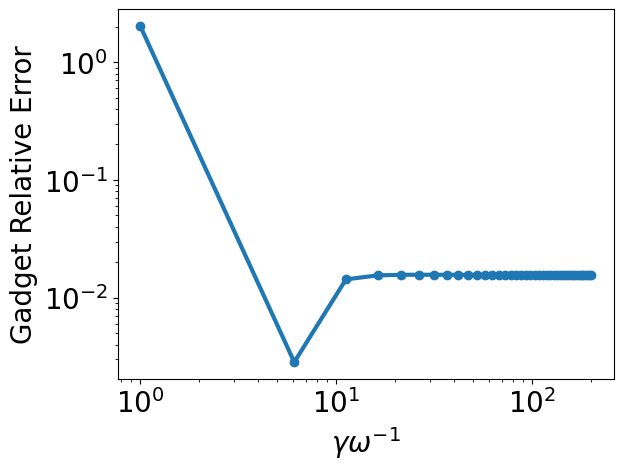

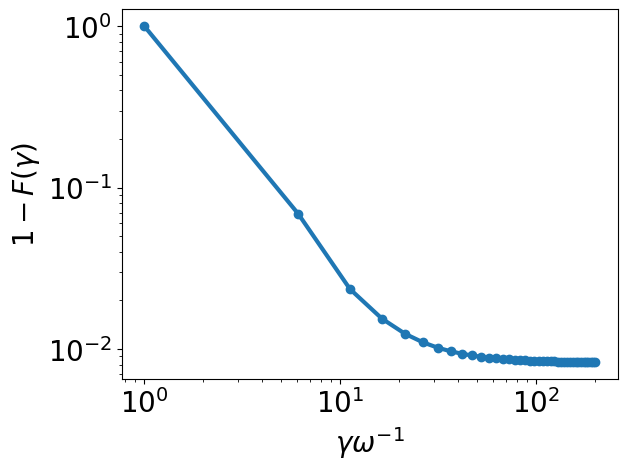

In [30]:
plt.plot(gammas,energy_error,linewidth=3,marker='o')
plt.xlabel(r'$\gamma \omega^{-1}$',fontsize=20)
plt.ylabel('Gadget Relative Error',fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas,1-np.array(fidelities),linewidth=3,marker='o')
plt.xlabel(r'$\gamma \omega^{-1}$',fontsize=20)
plt.ylabel(r'$1-F(\gamma)$',fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()



#### What about the state preparation using QA then ??

In [33]:
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
fidelities=[]
energy_error=[]
gammas=np.linspace(1,50,10)
for gamma in gammas:
    # get the total particle constrain 
    ntot=1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field=(diagonal_elements+0.5*(d_opt**2).sum())/(gamma)


    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz=0.
    for i in range(n_qubits):
        for j in range(i+1,n_qubits):
            hamiltonian_zz+=SpinOperator([('qz',i,'qz',j)],coupling=[2*gamma],size=n_qubits,verbose=1).qutip_op

    # then the linear terms
    hamiltonian_z=0.
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z+=SpinOperator([('qz',i)],coupling=[effective_longitudinal_field[i]+gamma*(1-2*ntot)],size=n_qubits,verbose=1).qutip_op

    #finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space=qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian=hamiltonian_zz+hamiltonian_z+gamma*(ntot**2)*identity_qubit_space
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian+=SpinOperator([('x',i)],coupling=[d_opt[i]/(np.sqrt(2))],size=n_qubits,verbose=1).qutip_op
    #### Initialize the state and convert the hamiltonians

    total_hamiltonian_sparse=(total_hamiltonian.data.as_scipy())
    driver_hamiltonian_sparse=(driver_hamiltonian.data.as_scipy() )
    #initialize the state
    psi=np.zeros(basis.shape[0])
    psi[idx_init]=1.



    #### start the time evolution

    nlevels=3
    tau=30*gamma
    time_steps=int(10*tau)
    time=np.linspace(0,tau,time_steps)
    delta_t=time[1]-time[0]
    spectrum=np.zeros((time_steps,nlevels))
    energy=np.zeros(time_steps)
    for i,t in enumerate(time):
        hamiltonian_t_sparse=(1-t/tau)*driver_hamiltonian_sparse+(t/tau)*total_hamiltonian_sparse
        psi=expm_multiply(-1j*delta_t*hamiltonian_t_sparse,psi)
        #eigenvalues, eigenvectors = eigsh(hamiltonian_t_sparse, k=nlevels, which='SA')
        #idx = np.argsort(eigenvalues)
        #eigenvalues = eigenvalues[idx]
        #eigenvectors = eigenvectors[:, idx]
        #spectrum[i] = eigenvalues
        energy[i]=psi.conj().dot(hamiltonian_t_sparse.dot( psi))
    psi_qutip=array_to_qutip(psi,n_qubits)
    energy_error.append(np.abs(energy[-1]*gamma-value[0])/np.abs(value[0]))
    f_value=fidelity(psi_qutip,eigenstates_total_hamiltonian[0])
    fidelities.append(f_value)
    print(gamma)
    print('energy=',energy[-1]*gamma)
    print('fidelity=',fidelity(psi_qutip,eigenstates_total_hamiltonian[0]))
    

/tmp/ipykernel_32436/2205738020.py:60: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i]=psi.conj().dot(hamiltonian_t_sparse.dot( psi))


1.0
energy= -44.5101179378176
fidelity= 0.02241720618027886
6.444444444444445
energy= -19.684531337229892
fidelity= 0.9414365865260547
11.88888888888889
energy= -19.366814052412057
fidelity= 0.9604241411894593
17.333333333333336
energy= -19.297355173886295
fidelity= 0.9479805399246807
22.77777777777778
energy= -19.243321764924282
fidelity= 0.93140492006627
28.22222222222222
energy= -19.19534669988967
fidelity= 0.9148198900264606
33.66666666666667
energy= -19.15276634510647
fidelity= 0.8993518474164377
39.111111111111114
energy= -19.115124717106976
fidelity= 0.8852611788114201
44.55555555555556
energy= -19.081830842483942
fidelity= 0.8725191142031116
50.0
energy= -19.052280441446776
fidelity= 0.861004723582253


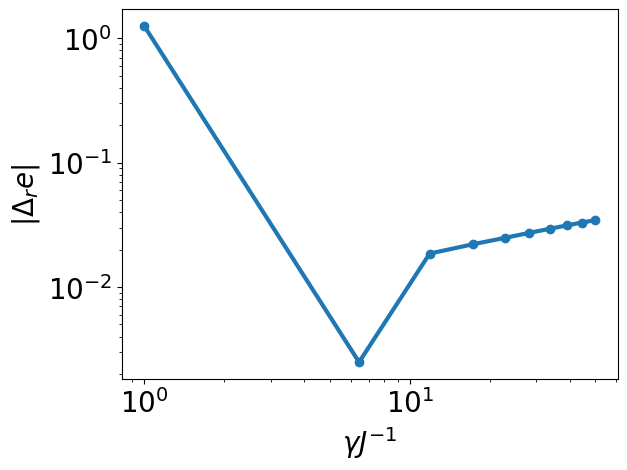

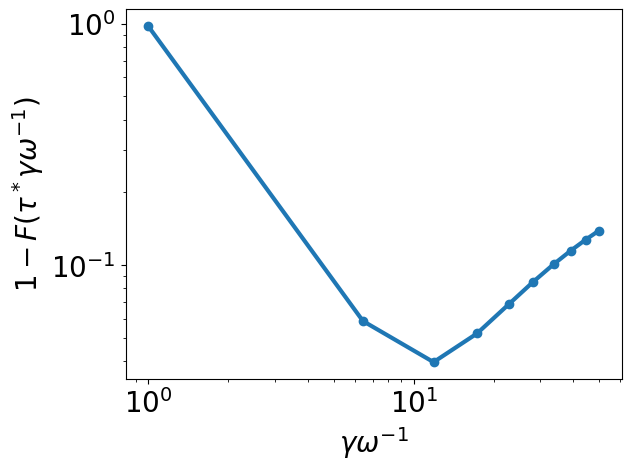

In [36]:
plt.plot(gammas[:len(energy_error)],energy_error,linewidth=3,marker='o')
plt.xlabel(r'$\gamma J^{-1}$',fontsize=20)
plt.ylabel(r'$|\Delta_r e|$',fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas[:len(energy_error)],1-np.array(fidelities),linewidth=3,marker='o')
plt.xlabel(r'$\gamma \omega^{-1}$',fontsize=20)
plt.ylabel(r'$1-F(\tau^* \gamma \omega^{-1} )$',fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()
